In [1]:
import dask.array as da
import joblib
import xarray as xr
from dask_ml.wrappers import ParallelPostFit
from datacube.utils.geometry import assign_crs
from xarray import Dataset
from pystac_client import Client
from odc.stac import load
import os
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.transform import from_origin

from planetary_computer import sign_url

/tmp/ipykernel_1498/2887921316.py:5: DeprecationWarning: datacube.utils.geometry is now deprecated. Please use the odc-geo library instead.
  from datacube.utils.geometry import assign_crs


In [2]:
DEP_CATALOG = "https://stac.digitalearthpacific.org"
# DEP_CATALOG = "https://stac.staging.digitalearthpacific.io"
MSPC_CATALOG = "https://planetarycomputer.microsoft.com/api/stac/v1/"

In [3]:
bbox = [178.43507, -17.05120, 179.19, -16.36]

chunks={"x": 2048, "y": 2048}

In [4]:
mspc_client = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1/")

# Get a pystac client for the MSPC
items_dem = list(mspc_client.search(collections=["cop-dem-glo-30"], bbox=bbox).items())


In [5]:
data = load(items_dem, measurements="data",
        bbox=bbox,
        chunks={"x": 2048, "y": 2048},
        groupby="solar_day",
    )

In [6]:
data_dem = load(items_dem, chunks=chunks, groupby="solar_day", like=data, patch_url=sign_url)

In [7]:
data_dem = (data_dem.where(data_dem != -32768).rename({"data": "elevation"}).squeeze("time"))


In [8]:
data_dem

<xarray.Dataset> Size: 27MB
Dimensions:      (latitude: 2489, longitude: 2719)
Coordinates:
  * latitude     (latitude) float64 20kB -16.36 -16.36 -16.36 ... -17.05 -17.05
  * longitude    (longitude) float64 22kB 178.4 178.4 178.4 ... 179.2 179.2
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2021-04-22
Data variables:
    elevation    (latitude, longitude) float32 27MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

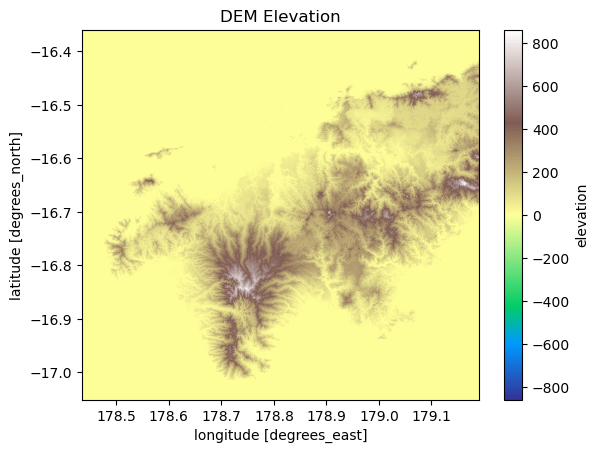

In [9]:
# If you have a DataArray
data_dem['elevation'].plot(cmap='terrain')
plt.title("DEM Elevation")
plt.show()

In [10]:
dem = data_dem['elevation']

In [11]:
height, width = dem.shape
left, right, bottom, top = bbox

pixel_width = (right - left) / width
pixel_height = (top - bottom) / height

transform = from_origin(left, top, pixel_width, pixel_height)  # top left corner

with rio.open(
    "0-dem.tif", "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=dem.dtype,
    crs="EPSG:32760",  # update if you know your DEM's CRS is different
    transform=transform,
    nodata=0  # or use -9999 if 0 is valid in your data
) as dst:
    dst.write(dem, 1)

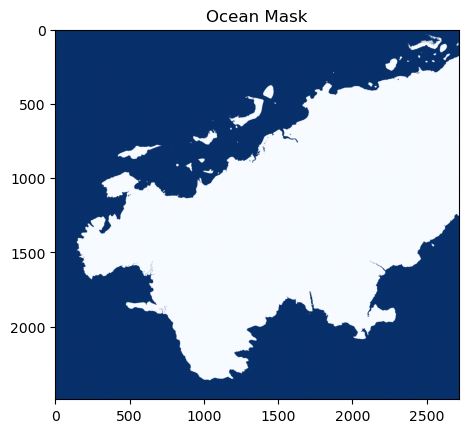

In [12]:
ocean_mask = np.where(dem == 0, 1, 0)  # 1 for ocean, 0 for land

plt.imshow(ocean_mask, cmap='Blues')
plt.title('Ocean Mask')
plt.show()

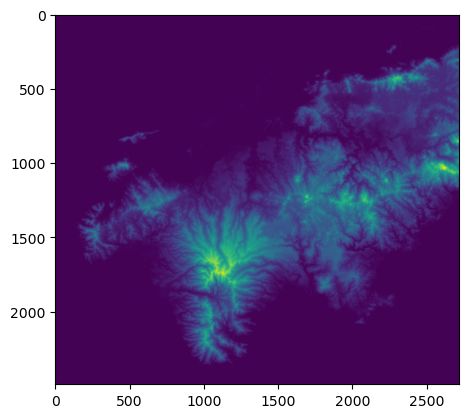

In [13]:
nodata_value = -9999
dem_nodata = np.where(np.isnan(dem), nodata_value, dem).astype(np.float32)
plt.imshow(dem)

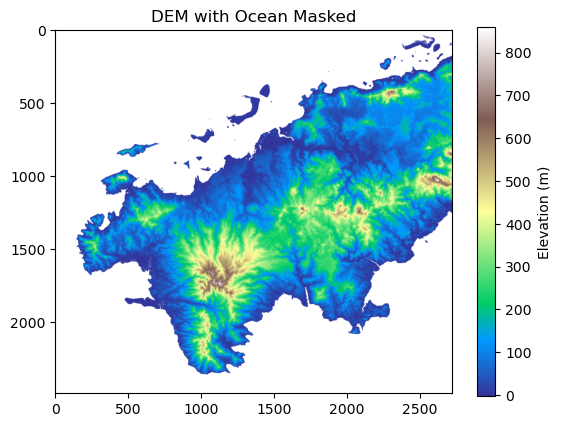

In [14]:
dem_masked = np.where(dem_nodata == 0, np.nan, dem_nodata)

# Example DEM array: ocean cells are np.nan, land is elevation
# dem_masked = np.where(dem_nodata == 0, np.nan, dem_nodata)

cmap = plt.get_cmap('terrain').copy()
cmap.set_bad(color='white')  # set color for ocean (masked np.nan)

im = plt.imshow(dem_masked, cmap=cmap)
plt.title('DEM with Ocean Masked')
cbar = plt.colorbar(im, label='Elevation (m)')

In [15]:
height, width = dem_masked.shape
left, right, bottom, top = bbox

pixel_width = (right - left) / width
pixel_height = (top - bottom) / height

transform = from_origin(left, top, pixel_width, pixel_height)  # top left corner

#### 1. Write unprocessed digital elevation model to disk

##### Output: `1-dem-masked`

In [16]:
with rio.open(
    "1-dem-masked.tif", "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=dem_masked.dtype,
    crs="EPSG:32760",  # update if you know your DEM's CRS is different
    transform=transform,
    nodata=0  # or use -9999 if 0 is valid in your data
) as dst:
    dst.write(dem_masked, 1)